# E6 — Opinion Weight × Confidence Bound

Аналіз результатів експерименту **E6 opinion-weight**.

У цьому експерименті:

- `wom-on? = true` для всіх запусків;
- `network-topology = preferential-attachment`;
- `network-degree = 6`;
- змінюються:
  - `purchase-deliberation-mode`;
  - `confidence-bound`;
  - `opinion-weight`.

Тому логіка E5, де ефект рахувався як `WOM ON − WOM OFF`, тут непридатна.

Для E6 контрольний сценарій:

```text
opinion-weight = 0
```

За цього значення opinion існує, але не впливає на target choice.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.family"] = "DejaVu Sans"

DATA_PATH = Path("./experiments/e6/table.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Файл не знайдено: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH, skiprows=6)
df = df.dropna(axis=1, how="all")
df.columns = [str(column).strip() for column in df.columns]

print("Shape:", df.shape)
display(df.head())


Shape: (2700, 29)


,[run number],number-of-shoppers,reward-cycles,reward-duration,withdrawal-duration,low-reward-salience,high-reward-salience,wom-on?,network-topology,network-degree,...,high-reward-withdrawal-drop,high-reward-retention-ratio,"persistence-index ""high-salience""","mean-intrinsic-motivation ""high-salience""","mean-habit ""high-salience""","mean-opinion ""high-salience""",wom-speaker-share,wom-receiver-share,mean-absolute-wom-opinion-change,mean-network-degree
0,6,1000,1,60,80,0.15,0.75,True,preferential-attachment,6,...,0.398098,0.506943,0.049049,0.408309,0.391441,0.075176,0.063,0.055,0.002054,5.988
1,4,1000,1,60,80,0.15,0.75,True,preferential-attachment,6,...,0.388301,0.523156,0.044432,0.415691,0.402703,0.070992,0.053,0.041,0.001501,5.988
2,1,1000,1,60,80,0.15,0.75,True,preferential-attachment,6,...,0.385398,0.525116,0.035773,0.416942,0.395495,0.069405,0.060,0.048,0.001999,5.988
3,9,1000,1,60,80,0.15,0.75,True,preferential-attachment,6,...,0.401239,0.505597,0.048561,0.416378,0.376276,0.061084,0.081,0.062,0.002045,5.988
4,8,1000,1,60,80,0.15,0.75,True,preferential-attachment,6,...,0.385135,0.527189,0.054655,0.410558,0.390240,0.072516,0.076,0.064,0.002157,5.988


## 1. Перевірка колонок

In [2]:
for column in df.columns:
    print(repr(column))


'[run number]'
'number-of-shoppers'
'reward-cycles'
'reward-duration'
'withdrawal-duration'
'low-reward-salience'
'high-reward-salience'
'wom-on?'
'network-topology'
'network-degree'
'rewiring-probability'
'purchase-deliberation-mode'
'confidence-bound'
'show-network?'
'opinion-weight'
'[step]'
'choice-rate "high-salience" "baseline"'
'choice-rate "high-salience" "reward"'
'final-withdrawal-choice-rate "high-salience"'
'high-reward-withdrawal-drop'
'high-reward-retention-ratio'
'persistence-index "high-salience"'
'mean-intrinsic-motivation "high-salience"'
'mean-habit "high-salience"'
'mean-opinion "high-salience"'
'wom-speaker-share'
'wom-receiver-share'
'mean-absolute-wom-opinion-change'
'mean-network-degree'


In [3]:
TARGET = 'final-withdrawal-choice-rate "high-salience"'
REWARD_RATE = 'choice-rate "high-salience" "reward"'
MEAN_OPINION = 'mean-opinion "high-salience"'

FACTORS = [
    "purchase-deliberation-mode",
    "confidence-bound",
    "opinion-weight",
]

required_columns = FACTORS + [TARGET, REWARD_RATE, MEAN_OPINION]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        "У CSV відсутні потрібні колонки:\n- "
        + "\n- ".join(missing_columns)
    )

print("Factors:", FACTORS)
print("Target:", TARGET)


Factors: ['purchase-deliberation-mode', 'confidence-bound', 'opinion-weight']
Target: final-withdrawal-choice-rate "high-salience"


## 2. Перевірка експериментального дизайну

In [4]:
design_columns = [
    "wom-on?",
    "network-topology",
    "network-degree",
    "purchase-deliberation-mode",
    "confidence-bound",
    "opinion-weight",
]

for column in design_columns:
    values = sorted(df[column].dropna().unique().tolist())
    print(f"{column}: {values}")


wom-on?: [True]
network-topology: ['preferential-attachment']
network-degree: [6]
purchase-deliberation-mode: ['high-involvement', 'low-involvement']
confidence-bound: [0.25, 0.5, 0.75, 0.9, 1.0]
opinion-weight: [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]


In [5]:
numeric_columns = [
    "confidence-bound",
    "opinion-weight",
    TARGET,
    REWARD_RATE,
    MEAN_OPINION,
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

invalid_rows = df[required_columns].isna().any(axis=1).sum()
print("Invalid rows:", invalid_rows)

df = df.dropna(subset=required_columns).copy()
print("Clean rows:", len(df))


Invalid rows: 0
Clean rows: 2700


## 3. Описова статистика

In [6]:
summary = (
    df.groupby(FACTORS, dropna=False)[TARGET]
      .agg(mean="mean", std="std", count="count")
      .reset_index()
)

summary["se"] = summary["std"] / np.sqrt(summary["count"])
summary["ci95_low"] = summary["mean"] - 1.96 * summary["se"]
summary["ci95_high"] = summary["mean"] + 1.96 * summary["se"]

display(
    summary.sort_values("mean", ascending=False).head(20)
)


,purchase-deliberation-mode,confidence-bound,opinion-weight,mean,std,count,se,ci95_low,ci95_high
44,high-involvement,1.00,5.0,0.714447,0.007716,30,0.001409,0.711686,0.717208
17,high-involvement,0.50,5.0,0.712685,0.009024,30,0.001647,0.709456,0.715914
26,high-involvement,0.75,5.0,0.712217,0.008519,30,0.001555,0.709169,0.715266
35,high-involvement,0.90,5.0,0.710922,0.007734,30,0.001412,0.708155,0.713690
8,high-involvement,0.25,5.0,0.704194,0.011449,30,0.002090,0.700097,0.708291
80,low-involvement,0.90,5.0,0.681155,0.009029,30,0.001649,0.677924,0.684386
89,low-involvement,1.00,5.0,0.680490,0.009815,30,0.001792,0.676978,0.684003
71,low-involvement,0.75,5.0,0.680236,0.012247,30,0.002236,0.675854,0.684619
53,low-involvement,0.25,5.0,0.679342,0.010330,30,0.001886,0.675645,0.683038
62,low-involvement,0.50,5.0,0.678214,0.009204,30,0.001680,0.674921,0.681508


## 4. Базовий сценарій: `opinion-weight = 0`

Для кожного deliberation mode базове значення обчислюється як середнє всіх запусків із `opinion-weight = 0`.

`confidence-bound` за нульової ваги opinion не повинен впливати на target choice, тому ці значення об'єднуються.


In [7]:
baseline = (
    df[df["opinion-weight"] == 0]
    .groupby("purchase-deliberation-mode")[TARGET]
    .agg(
        baseline_mean="mean",
        baseline_std="std",
        baseline_count="count",
    )
    .reset_index()
)

if baseline.empty:
    raise ValueError(
        "У CSV відсутні запуски з opinion-weight = 0."
    )

display(baseline)


,purchase-deliberation-mode,baseline_mean,baseline_std,baseline_count
0,high-involvement,0.419581,0.007947,150
1,low-involvement,0.417846,0.007878,150


## 5. Ефект opinion на target choice

In [8]:
effects = summary.merge(
    baseline,
    on="purchase-deliberation-mode",
    how="left",
    validate="many_to_one",
)

effects["absolute_effect"] = (
    effects["mean"] - effects["baseline_mean"]
)

effects["relative_uplift"] = np.where(
    effects["baseline_mean"] != 0,
    effects["absolute_effect"] / effects["baseline_mean"],
    np.nan,
)

display(
    effects.sort_values(
        "absolute_effect",
        ascending=False
    ).head(20)
)


,purchase-deliberation-mode,confidence-bound,opinion-weight,mean,std,count,se,ci95_low,ci95_high,baseline_mean,baseline_std,baseline_count,absolute_effect,relative_uplift
44,high-involvement,1.00,5.0,0.714447,0.007716,30,0.001409,0.711686,0.717208,0.419581,0.007947,150,0.294866,0.702762
17,high-involvement,0.50,5.0,0.712685,0.009024,30,0.001647,0.709456,0.715914,0.419581,0.007947,150,0.293104,0.698563
26,high-involvement,0.75,5.0,0.712217,0.008519,30,0.001555,0.709169,0.715266,0.419581,0.007947,150,0.292636,0.697447
35,high-involvement,0.90,5.0,0.710922,0.007734,30,0.001412,0.708155,0.713690,0.419581,0.007947,150,0.291341,0.694361
8,high-involvement,0.25,5.0,0.704194,0.011449,30,0.002090,0.700097,0.708291,0.419581,0.007947,150,0.284613,0.678326
80,low-involvement,0.90,5.0,0.681155,0.009029,30,0.001649,0.677924,0.684386,0.417846,0.007878,150,0.263309,0.630159
89,low-involvement,1.00,5.0,0.680490,0.009815,30,0.001792,0.676978,0.684003,0.417846,0.007878,150,0.262645,0.628569
71,low-involvement,0.75,5.0,0.680236,0.012247,30,0.002236,0.675854,0.684619,0.417846,0.007878,150,0.262391,0.627961
53,low-involvement,0.25,5.0,0.679342,0.010330,30,0.001886,0.675645,0.683038,0.417846,0.007878,150,0.261496,0.625820
62,low-involvement,0.50,5.0,0.678214,0.009204,30,0.001680,0.674921,0.681508,0.417846,0.007878,150,0.260369,0.623122


## 6. Частка компенсованого падіння

Розрахунок:

```text
compensation_ratio =
(effect relative to opinion-weight = 0)
/
(reward choice rate at weight = 0 − withdrawal choice rate at weight = 0)
```


In [9]:
baseline_reward = (
    df[df["opinion-weight"] == 0]
    .groupby("purchase-deliberation-mode")[REWARD_RATE]
    .mean()
    .rename("baseline_reward_mean")
    .reset_index()
)

effects = effects.merge(
    baseline_reward,
    on="purchase-deliberation-mode",
    how="left",
    validate="many_to_one",
)

effects["baseline_withdrawal_drop"] = (
    effects["baseline_reward_mean"]
    - effects["baseline_mean"]
)

effects["compensation_ratio"] = np.where(
    effects["baseline_withdrawal_drop"] > 0,
    effects["absolute_effect"]
    / effects["baseline_withdrawal_drop"],
    np.nan,
)

display(
    effects.sort_values(
        "compensation_ratio",
        ascending=False
    ).head(20)
)


,purchase-deliberation-mode,confidence-bound,opinion-weight,mean,std,count,se,ci95_low,ci95_high,baseline_mean,baseline_std,baseline_count,absolute_effect,relative_uplift,baseline_reward_mean,baseline_withdrawal_drop,compensation_ratio
44,high-involvement,1.00,5.0,0.714447,0.007716,30,0.001409,0.711686,0.717208,0.419581,0.007947,150,0.294866,0.702762,0.809152,0.389571,0.756899
17,high-involvement,0.50,5.0,0.712685,0.009024,30,0.001647,0.709456,0.715914,0.419581,0.007947,150,0.293104,0.698563,0.809152,0.389571,0.752376
26,high-involvement,0.75,5.0,0.712217,0.008519,30,0.001555,0.709169,0.715266,0.419581,0.007947,150,0.292636,0.697447,0.809152,0.389571,0.751175
35,high-involvement,0.90,5.0,0.710922,0.007734,30,0.001412,0.708155,0.713690,0.419581,0.007947,150,0.291341,0.694361,0.809152,0.389571,0.747851
8,high-involvement,0.25,5.0,0.704194,0.011449,30,0.002090,0.700097,0.708291,0.419581,0.007947,150,0.284613,0.678326,0.809152,0.389571,0.730581
80,low-involvement,0.90,5.0,0.681155,0.009029,30,0.001649,0.677924,0.684386,0.417846,0.007878,150,0.263309,0.630159,0.809020,0.391174,0.673125
89,low-involvement,1.00,5.0,0.680490,0.009815,30,0.001792,0.676978,0.684003,0.417846,0.007878,150,0.262645,0.628569,0.809020,0.391174,0.671427
71,low-involvement,0.75,5.0,0.680236,0.012247,30,0.002236,0.675854,0.684619,0.417846,0.007878,150,0.262391,0.627961,0.809020,0.391174,0.670777
53,low-involvement,0.25,5.0,0.679342,0.010330,30,0.001886,0.675645,0.683038,0.417846,0.007878,150,0.261496,0.625820,0.809020,0.391174,0.668490
62,low-involvement,0.50,5.0,0.678214,0.009204,30,0.001680,0.674921,0.681508,0.417846,0.007878,150,0.260369,0.623122,0.809020,0.391174,0.665608


## 7. Opinion weight → final withdrawal choice rate

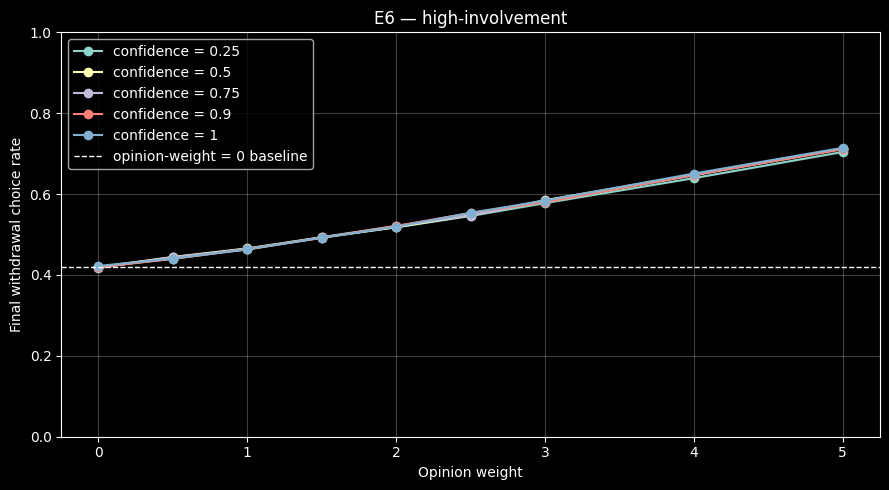

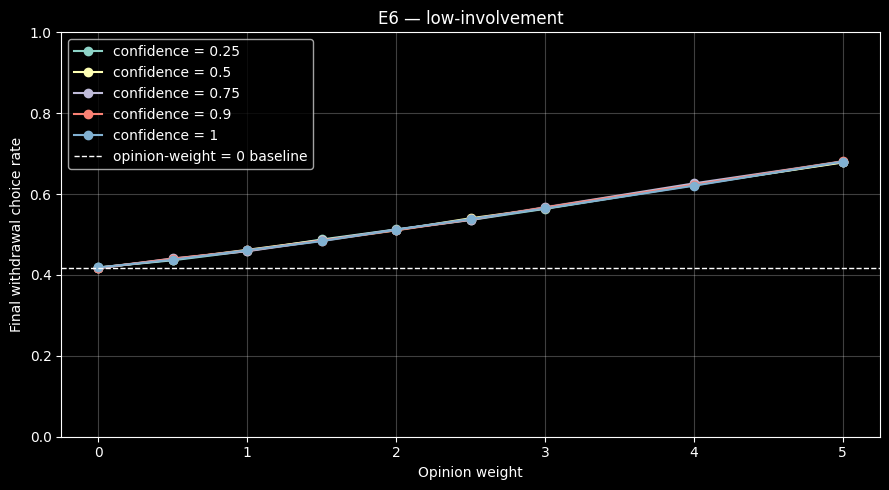

In [10]:
for mode, mode_data in summary.groupby(
    "purchase-deliberation-mode"
):
    plt.figure()

    for confidence, group in mode_data.groupby(
        "confidence-bound"
    ):
        group = group.sort_values("opinion-weight")

        plt.plot(
            group["opinion-weight"],
            group["mean"],
            marker="o",
            label=f"confidence = {confidence:g}",
        )

        plt.fill_between(
            group["opinion-weight"],
            group["ci95_low"],
            group["ci95_high"],
            alpha=0.12,
        )

    baseline_value = baseline.loc[
        baseline["purchase-deliberation-mode"] == mode,
        "baseline_mean",
    ].iloc[0]

    plt.axhline(
        baseline_value,
        linestyle="--",
        linewidth=1,
        label="opinion-weight = 0 baseline",
    )

    plt.xlabel("Opinion weight")
    plt.ylabel("Final withdrawal choice rate")
    plt.title(f"E6 — {mode}")
    plt.ylim(0, 1)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 8. Видимий ефект відносно `opinion-weight = 0`

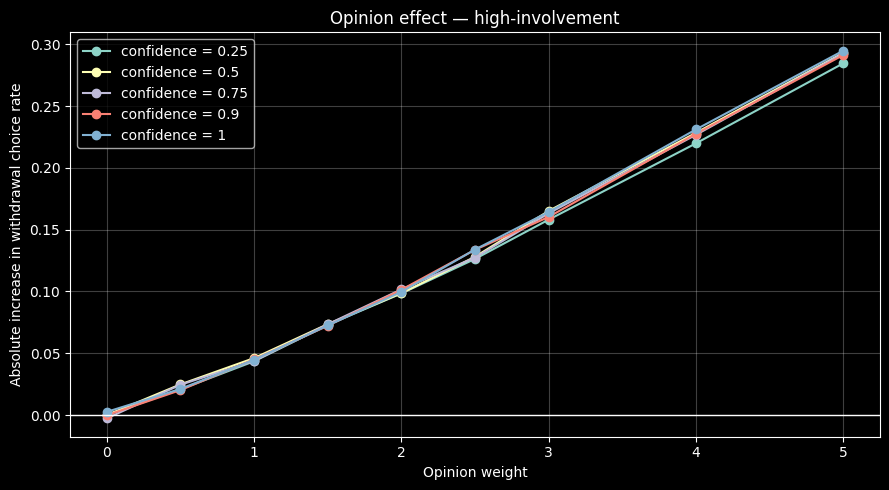

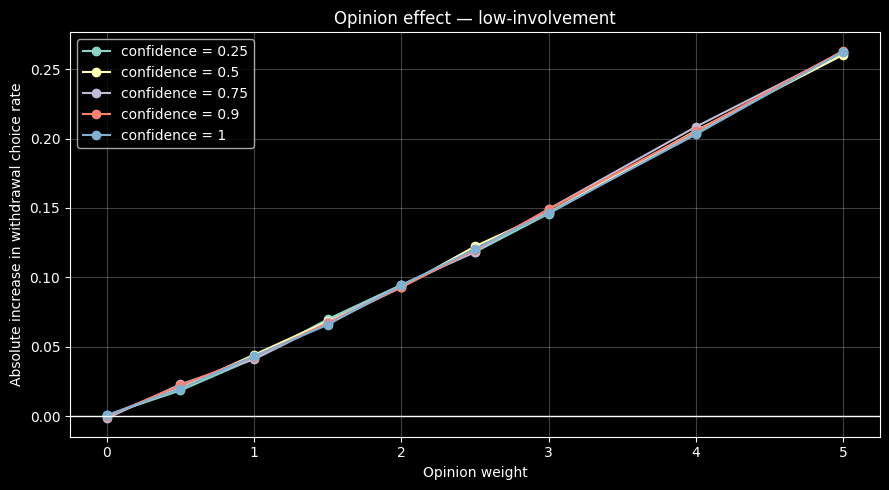

In [11]:
for mode, mode_data in effects.groupby(
    "purchase-deliberation-mode"
):
    plt.figure()

    for confidence, group in mode_data.groupby(
        "confidence-bound"
    ):
        group = group.sort_values("opinion-weight")

        plt.plot(
            group["opinion-weight"],
            group["absolute_effect"],
            marker="o",
            label=f"confidence = {confidence:g}",
        )

    plt.axhline(0, linewidth=1)
    plt.xlabel("Opinion weight")
    plt.ylabel("Absolute increase in withdrawal choice rate")
    plt.title(f"Opinion effect — {mode}")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 9. Heatmap: opinion weight × confidence bound

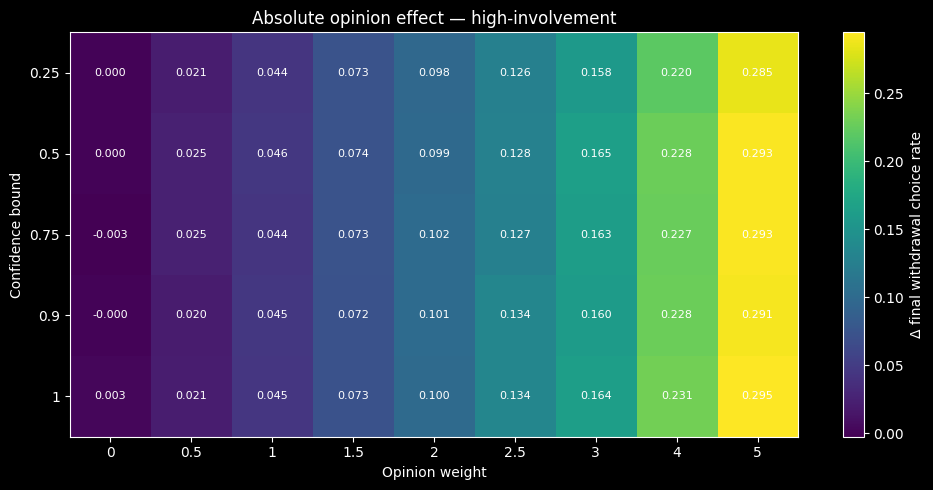

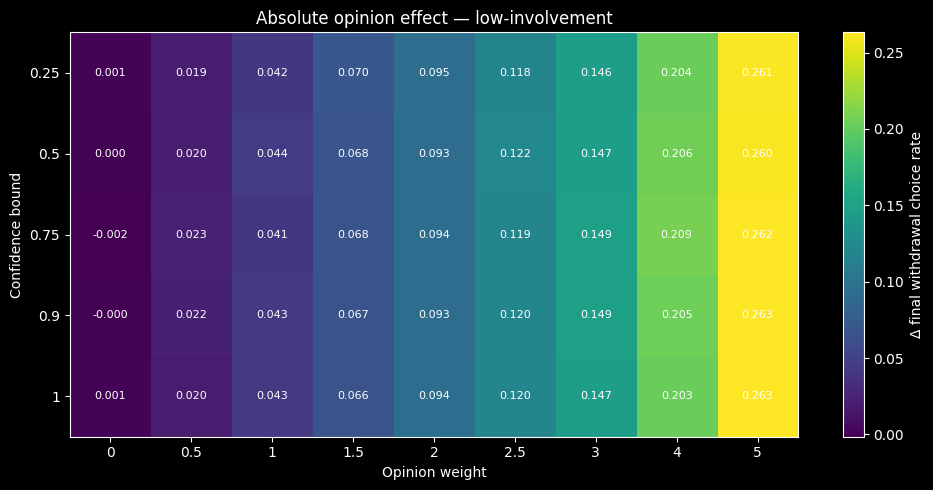

In [12]:
def draw_heatmap(data, value_column, title, label):
    pivot = (
        data.pivot(
            index="confidence-bound",
            columns="opinion-weight",
            values=value_column,
        )
        .sort_index()
        .sort_index(axis=1)
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    image = ax.imshow(pivot.values, aspect="auto")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([
        f"{value:g}" for value in pivot.columns
    ])

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([
        f"{value:g}" for value in pivot.index
    ])

    ax.set_xlabel("Opinion weight")
    ax.set_ylabel("Confidence bound")
    ax.set_title(title)

    for row in range(len(pivot.index)):
        for column in range(len(pivot.columns)):
            value = pivot.iloc[row, column]
            ax.text(
                column,
                row,
                f"{value:.3f}",
                ha="center",
                va="center",
                fontsize=8,
            )

    fig.colorbar(image, ax=ax, label=label)
    plt.tight_layout()
    plt.show()


for mode, mode_data in effects.groupby(
    "purchase-deliberation-mode"
):
    draw_heatmap(
        mode_data,
        "absolute_effect",
        f"Absolute opinion effect — {mode}",
        "Δ final withdrawal choice rate",
    )


## 10. Mean opinion

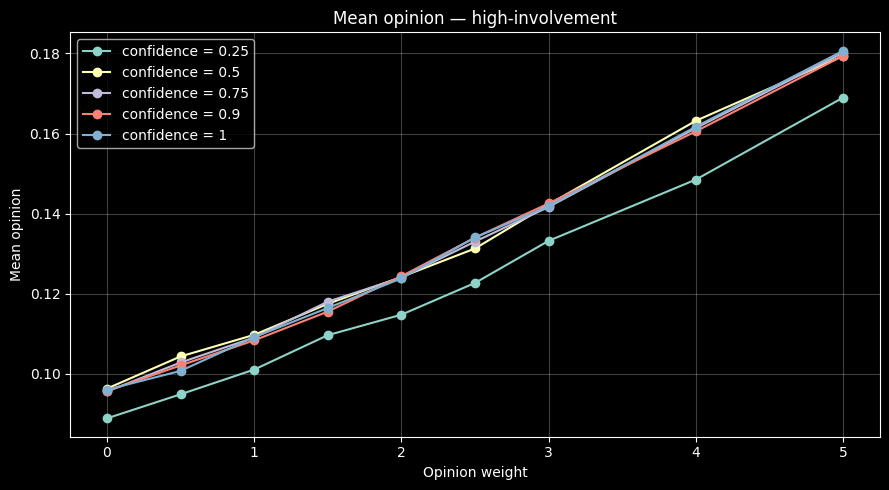

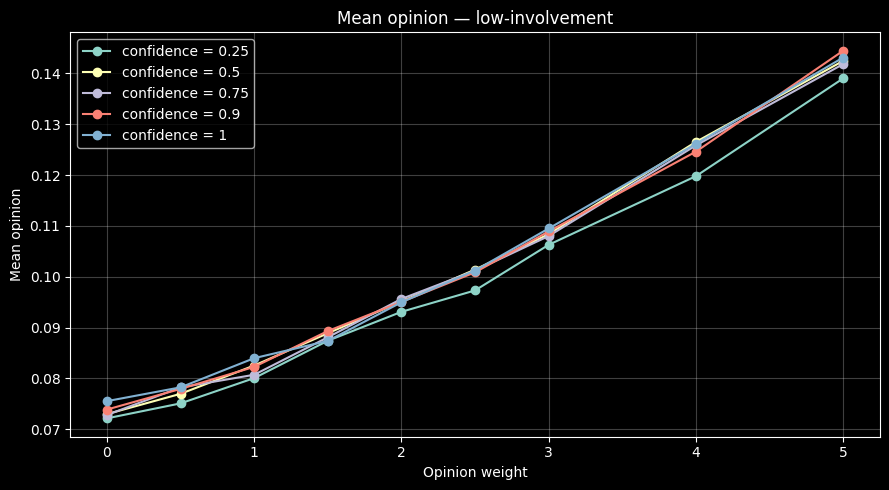

In [13]:
opinion_summary = (
    df.groupby(FACTORS)[MEAN_OPINION]
      .agg(
          mean_opinion="mean",
          std_opinion="std",
          count="count",
      )
      .reset_index()
)

for mode, mode_data in opinion_summary.groupby(
    "purchase-deliberation-mode"
):
    plt.figure()

    for confidence, group in mode_data.groupby(
        "confidence-bound"
    ):
        group = group.sort_values("opinion-weight")

        plt.plot(
            group["opinion-weight"],
            group["mean_opinion"],
            marker="o",
            label=f"confidence = {confidence:g}",
        )

    plt.xlabel("Opinion weight")
    plt.ylabel("Mean opinion")
    plt.title(f"Mean opinion — {mode}")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 11. Рейтинг конфігурацій

In [14]:
ranking_columns = [
    "purchase-deliberation-mode",
    "confidence-bound",
    "opinion-weight",
    "mean",
    "baseline_mean",
    "absolute_effect",
    "relative_uplift",
    "compensation_ratio",
    "ci95_low",
    "ci95_high",
    "count",
]

ranking = (
    effects[ranking_columns]
    .sort_values(
        ["absolute_effect", "mean"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

display(ranking.head(30))


,purchase-deliberation-mode,confidence-bound,opinion-weight,mean,baseline_mean,absolute_effect,relative_uplift,compensation_ratio,ci95_low,ci95_high,count
0,high-involvement,1.00,5.0,0.714447,0.419581,0.294866,0.702762,0.756899,0.711686,0.717208,30
1,high-involvement,0.50,5.0,0.712685,0.419581,0.293104,0.698563,0.752376,0.709456,0.715914,30
2,high-involvement,0.75,5.0,0.712217,0.419581,0.292636,0.697447,0.751175,0.709169,0.715266,30
3,high-involvement,0.90,5.0,0.710922,0.419581,0.291341,0.694361,0.747851,0.708155,0.713690,30
4,high-involvement,0.25,5.0,0.704194,0.419581,0.284613,0.678326,0.730581,0.700097,0.708291,30
5,low-involvement,0.90,5.0,0.681155,0.417846,0.263309,0.630159,0.673125,0.677924,0.684386,30
6,low-involvement,1.00,5.0,0.680490,0.417846,0.262645,0.628569,0.671427,0.676978,0.684003,30
7,low-involvement,0.75,5.0,0.680236,0.417846,0.262391,0.627961,0.670777,0.675854,0.684619,30
8,low-involvement,0.25,5.0,0.679342,0.417846,0.261496,0.625820,0.668490,0.675645,0.683038,30
9,low-involvement,0.50,5.0,0.678214,0.417846,0.260369,0.623122,0.665608,0.674921,0.681508,30


## 12. Автоматичне резюме

In [15]:
best = ranking.iloc[0]

print("Best E6 configuration")
print("---------------------")
print(
    "Deliberation mode:",
    best["purchase-deliberation-mode"],
)
print("Confidence bound:", best["confidence-bound"])
print("Opinion weight:", best["opinion-weight"])
print(f"Withdrawal choice rate: {best['mean']:.4f}")
print(f"Baseline: {best['baseline_mean']:.4f}")
print(f"Absolute effect: {best['absolute_effect']:.4f}")
print(
    f"Relative uplift: "
    f"{best['relative_uplift'] * 100:.2f}%"
)
print(
    f"Compensation ratio: "
    f"{best['compensation_ratio'] * 100:.2f}%"
)
print(
    "95% CI: "
    f"[{best['ci95_low']:.4f}; "
    f"{best['ci95_high']:.4f}]"
)


Best E6 configuration
---------------------
Deliberation mode: high-involvement
Confidence bound: 1.0
Opinion weight: 5.0
Withdrawal choice rate: 0.7144
Baseline: 0.4196
Absolute effect: 0.2949
Relative uplift: 70.28%
Compensation ratio: 75.69%
95% CI: [0.7117; 0.7172]


## 13. Експорт результатів

In [16]:
OUTPUT_DIR = Path("./experiments/e6/analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary.to_csv(
    OUTPUT_DIR / "e6_summary.csv",
    index=False,
)

effects.to_csv(
    OUTPUT_DIR / "e6_effects.csv",
    index=False,
)

ranking.to_csv(
    OUTPUT_DIR / "e6_ranking.csv",
    index=False,
)

print("Saved to:", OUTPUT_DIR.resolve())


Saved to: /Users/igor/projects/phd/loyalty-network-model/experiments/e6/analysis
